In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix,
                              classification_report,
                              ConfusionMatrixDisplay)

Dataset shape : (1797, 64)
Classes       : [0 1 2 3 4 5 6 7 8 9]


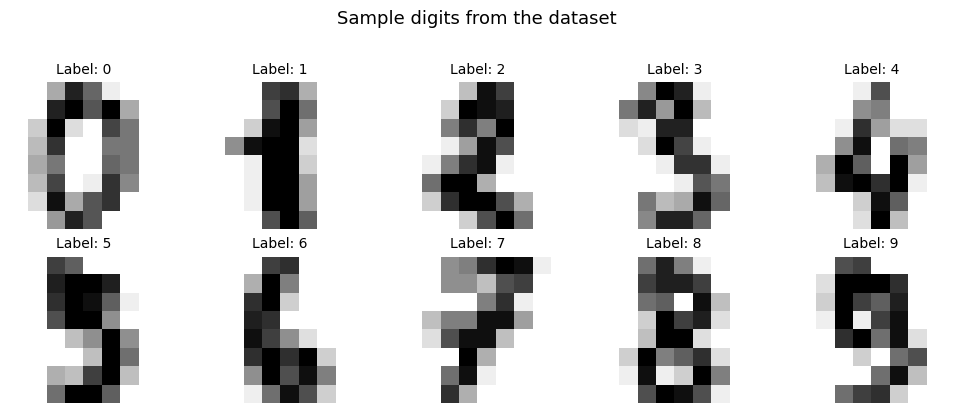

In [2]:
digits = load_digits()
X, y   = digits.data, digits.target

print(f"Dataset shape : {X.shape}")          # (1797, 64)
print(f"Classes       : {digits.target_names}")


fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis('off')
plt.suptitle("Sample digits from the dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best K        : 1
Best CV Score : 0.9861 (98.61%)


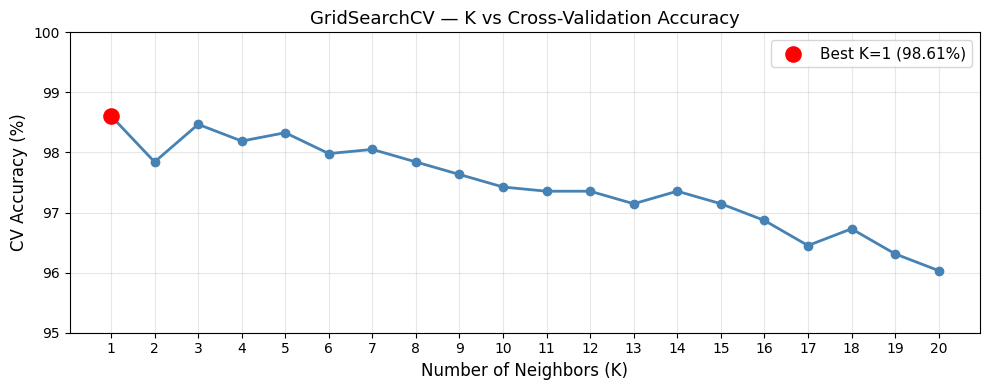

In [4]:
param_grid = {'n_neighbors': list(range(1, 21))}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_k     = grid_search.best_params_['n_neighbors']
best_cv    = grid_search.best_score_
cv_scores  = grid_search.cv_results_['mean_test_score']

print(f"\nBest K        : {best_k}")
print(f"Best CV Score : {best_cv:.4f} ({best_cv*100:.2f}%)")

plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), cv_scores * 100, 'o-', color='steelblue',
         linewidth=2, markersize=6)
plt.scatter([best_k], [best_cv * 100], color='red', s=120,
            zorder=5, label=f'Best K={best_k} ({best_cv*100:.2f}%)')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('CV Accuracy (%)', fontsize=12)
plt.title('GridSearchCV — K vs Cross-Validation Accuracy', fontsize=13)
plt.xticks(range(1, 21))
plt.ylim(95, 100)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred      = knn.predict(X_test)
test_score  = knn.score(X_test, y_test)

print(f"\nTest Accuracy : {test_score:.4f} ({test_score*100:.2f}%)")



Test Accuracy : 0.9778 (97.78%)


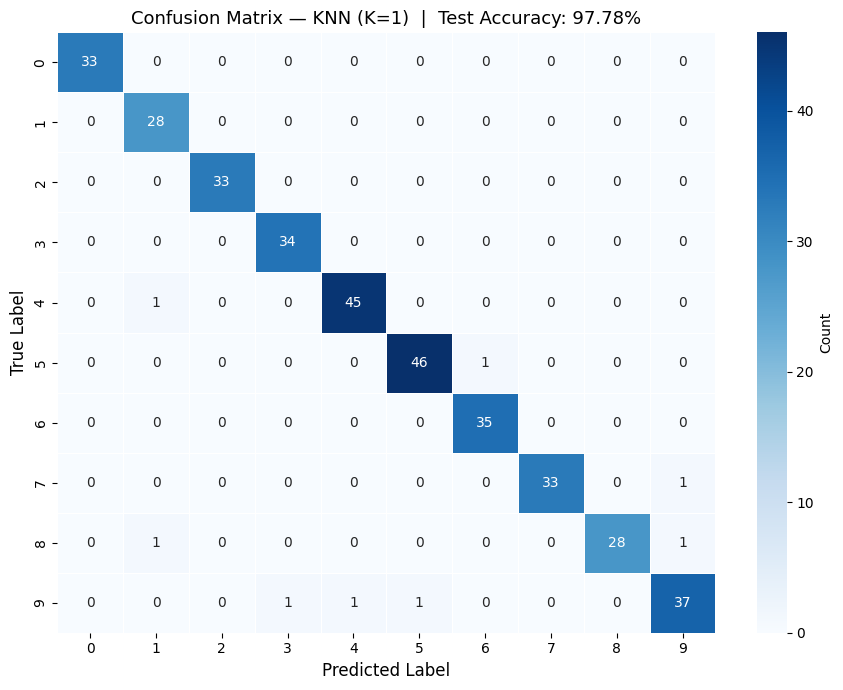

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=digits.target_names,
    yticklabels=digits.target_names,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix — KNN (K={best_k})  |  Test Accuracy: {test_score*100:.2f}%',
          fontsize=13)
plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



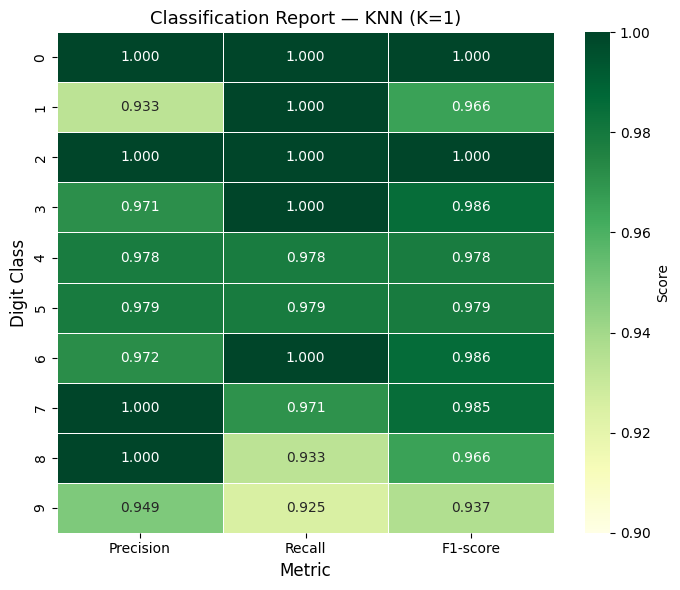

In [7]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in digits.target_names],
    output_dict=True
)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in digits.target_names]
))

report_df_data = {
    'Precision': [],
    'Recall':    [],
    'F1-score':  []
}
row_labels = [str(c) for c in digits.target_names]

for label in row_labels:
    report_df_data['Precision'].append(report_dict[label]['precision'])
    report_df_data['Recall'].append(report_dict[label]['recall'])
    report_df_data['F1-score'].append(report_dict[label]['f1-score'])

import pandas as pd
report_df = pd.DataFrame(report_df_data, index=row_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    report_df,
    annot=True,
    fmt='.3f',
    cmap='YlGn',
    vmin=0.90,
    vmax=1.00,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Score'}
)
plt.title(f'Classification Report — KNN (K={best_k})', fontsize=13)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Digit Class', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
print("=" * 45)
print(" SUMMARY")
print("=" * 45)
print(f"  Dataset        : sklearn digits (1797 samples, 10 classes)")
print(f"  Train samples  : {len(X_train)}")
print(f"  Test samples   : {len(X_test)}")
print(f"  Best K         : {best_k}  (GridSearchCV, K=1..20, cv=5)")
print(f"  CV Accuracy    : {best_cv*100:.2f}%")
print(f"  Test Accuracy  : {test_score*100:.2f}%")
print("=" * 45)

 SUMMARY
  Dataset        : sklearn digits (1797 samples, 10 classes)
  Train samples  : 1437
  Test samples   : 360
  Best K         : 1  (GridSearchCV, K=1..20, cv=5)
  CV Accuracy    : 98.61%
  Test Accuracy  : 97.78%
